# CSV data extraction

In [2]:
import csv

star_features = []

with open('variable_stars_features.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        # Convert string values to appropriate types
        star_dict = {}
        
        for key, value in row.items():
            # Handle None/empty values
            if value == '' or value == 'None' or value == 'nan':
                star_dict[key] = None
            # Keep object_id as string
            elif key == 'object_id':
                star_dict[key] = value
            # Convert is_binary to boolean
            elif key == 'is_binary':
                star_dict[key] = value.lower() == 'true' if value else None
            # Convert numeric fields to float
            else:
                try:
                    star_dict[key] = float(value)
                except (ValueError, TypeError):
                    star_dict[key] = None
        
        star_features.append(star_dict)

print(f"Loaded {len(star_features)} stars")
print(f"Features: {list(star_features[0].keys())}")
print(f"\nFirst star example:")
print(star_features[0])

Loaded 1005 stars
Features: ['object_id', 'is_binary', 'skewness', 'kurtosis', 'second_harmonic', 'period', 'amplitude', 'asymmetry_ratio', 'rise_time_fraction', 'bp_rp', 'second_harmonic_ratio', 'third_harmonic_ratio', 'ruwe', 'signal_to_noise', 'parallax']

First star example:
{'object_id': '229910234', 'is_binary': False, 'skewness': -1.100389850679286, 'kurtosis': 7.028908466882804, 'second_harmonic': 0.06132763640357768, 'period': 1.8928776718360187, 'amplitude': 0.021004323411077275, 'asymmetry_ratio': 0.9337401918047079, 'rise_time_fraction': 0.4828674481514878, 'bp_rp': 0.6598701477050781, 'second_harmonic_ratio': 0.08401527556984023, 'third_harmonic_ratio': 0.059089811079284654, 'ruwe': 1.0045229196548462, 'signal_to_noise': 8.611642805604088, 'parallax': 2.437262056252539}


# CSV class extraction

In [5]:
classifications = []

with open('AST424_Star Class - Sheet1.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)  # Use csv.reader instead of DictReader
    
    # Skip header row
    next(reader)
    
    for row in reader:
        # Skip empty rows
        if len(row) < 3 or not row[0].strip():
            continue
        
        classification = {
            'star_type': row[1].strip(),
            'star_id': row[2].strip()
        }
        classifications.append(classification)

print(f"Loaded {len(classifications)} classified stars")
print(classifications[0])

Loaded 574 classified stars
{'star_type': 'EB', 'star_id': '229910234'}


# Combine Dicts

In [8]:
'''
features_used = ['period', 'amplitude', 'asymmetry_ratio', 'rise_time_fraction', 'bp_rp', 'kurtosis', 'second_harmonic', 'is_binary']

j = 0
set_up_dicts = []
for star in star_features:
    cur_star = {}
    i = 0
    while(i <= len(features_used)):
        cur_star[features_used[i]] = star[features_used[i]]
        i += 1
    if star['object_id'] == classifications[j]['star_id']:
        cur_star['result'] = classifications[j]['star_type']
        if classification_dict[j]['star_type'] == 'EB':
            cur_star['is_binary'] = True
    else:
        print('Not a match')

    j += 1
    set_up_dicts.append(cur_star)
'''

"\nfeatures_used = ['period', 'amplitude', 'asymmetry_ratio', 'rise_time_fraction', 'bp_rp', 'kurtosis', 'second_harmonic', 'is_binary']\n\nj = 0\nset_up_dicts = []\nfor star in star_features:\n    cur_star = {}\n    i = 0\n    while(i <= len(features_used)):\n        cur_star[features_used[i]] = star[features_used[i]]\n        i += 1\n    if star['object_id'] == classifications[j]['star_id']:\n        cur_star['result'] = classifications[j]['star_type']\n        if classification_dict[j]['star_type'] == 'EB':\n            cur_star['is_binary'] = True\n    else:\n        print('Not a match')\n\n    j += 1\n    set_up_dicts.append(cur_star)\n"

In [10]:
features_used = ['period', 'amplitude', 'asymmetry_ratio', 'rise_time_fraction', 'bp_rp', 'kurtosis', 'second_harmonic', 'is_binary']

classification_dict = {c['star_id']: c['star_type'] for c in classifications}

set_up_dicts = []
for star in star_features:
    cur_star = {}
    
    for feature in features_used:
        cur_star[feature] = star.get(feature)
    
    star_id = str(star['object_id'])
    if star_id in classification_dict:
        cur_star['result'] = classification_dict[star_id]
        if classification_dict[star_id] == 'EB':
            cur_star['is_binary'] = True
        set_up_dicts.append(cur_star)
    else:
        print(f"No classification found for star {star_id}")

print(f"\nCreated {len(set_up_dicts)} training examples")
print(f"\nFirst example:")
print(set_up_dicts[0])

No classification found for star 233096169
No classification found for star 233128420
No classification found for star 233159217
No classification found for star 233159259
No classification found for star 233530521
No classification found for star 233689972
No classification found for star 233690111
No classification found for star 233690335
No classification found for star 233690597
No classification found for star 233714249
No classification found for star 233715139
No classification found for star 233721121
No classification found for star 233727422
No classification found for star 233738106
No classification found for star 233738219
No classification found for star 233738223
No classification found for star 233738458
No classification found for star 233739007
No classification found for star 424438647
No classification found for star 229738650
No classification found for star 233530521
No classification found for star 233722108
No classification found for star 233726761
No classifi

# ML format preparation

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.DataFrame(set_up_dicts)
df_clean = df.dropna()

print("=============================")

print("cleaning and showing dat")
feature_columns = ['period', 'amplitude', 'asymmetry_ratio', 
                   'rise_time_fraction', 'bp_rp', 'kurtosis', 
                   'second_harmonic', 'is_binary']

X = df_clean[feature_columns]
y = df_clean['result']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTarget classes: {y.unique()}")
print(f"Class distribution:")
print(y.value_counts())

counts = y.value_counts()

valid_classes = counts[counts > 3].index

df_clean_filtered = df_clean[df_clean['result'].isin(valid_classes)]

X = df_clean_filtered[feature_columns]
y = df_clean_filtered['result']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTarget classes: {y.unique()}")
print(f"Class distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep same class proportions
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

cleaning and showing dat
Features (X) shape: (707, 8)
Target (y) shape: (707,)

Target classes: ['EB' 'CC1' 'OSARG' 'BL' 'RGV' 'BY' 'MV' 'DSS' 'ROT' 'LPV' 'GDOR' 'BYS'
 'CC2' 'RRL' 'DSCT' 'SPB/ROT' 'EB/ROT' 'DSCT/EB' 'SPB' 'BY/EB' 'EB/DSCT'
 'NOID']
Class distribution:
result
RGV        219
ROT        160
EB          73
BY          72
OSARG       71
GDOR        26
DSS         19
DSCT        14
LPV         12
CC1          9
MV           8
NOID         5
SPB/ROT      3
EB/ROT       3
DSCT/EB      3
CC2          2
BL           2
BY/EB        2
RRL          1
SPB          1
EB/DSCT      1
BYS          1
Name: count, dtype: int64
Features (X) shape: (688, 8)
Target (y) shape: (688,)

Target classes: ['EB' 'CC1' 'OSARG' 'RGV' 'BY' 'MV' 'DSS' 'ROT' 'LPV' 'GDOR' 'DSCT' 'NOID']
Class distribution:
result
RGV      219
ROT      160
EB        73
BY        72
OSARG     71
GDOR      26
DSS       19
DSCT      14
LPV       12
CC1        9
MV         8
NOID       5
Name: count, dtype: int64
Training se

# ML

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_jobs=-1,
                       random_state=42)

In [22]:
y_pred = rf_model.predict(X_test)
print(f"Predictions made for {len(y_pred)} samples")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Predictions made for 138 samples

Test Accuracy: 0.7681 (76.81%)

Classification Report:
              precision    recall  f1-score   support

          BY       0.80      0.57      0.67        14
         CC1       0.00      0.00      0.00         2
        DSCT       0.50      0.33      0.40         3
         DSS       1.00      0.50      0.67         4
          EB       0.94      1.00      0.97        15
        GDOR       1.00      1.00      1.00         5
         LPV       0.00      0.00      0.00         2
          MV       0.00      0.00      0.00         2
        NOID       1.00      1.00      1.00         1
       OSARG       0.40      0.14      0.21        14
         RGV       0.71      0.95      0.82        44
         ROT       0.79      0.94      0.86        32

    accuracy                           0.77       138
   macro avg       0.59      0.54      0.55       138
weighted avg       0.72      0.77      0.72       138


Confusion Matrix:
[[ 8  0  0  0  0  0  0  0

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Feature Importance Ranking:
           feature  importance
             bp_rp    0.351287
            period    0.141321
         is_binary    0.127304
         amplitude    0.105870
          kurtosis    0.091706
   second_harmonic    0.075623
   asymmetry_ratio    0.053686
rise_time_fraction    0.053203


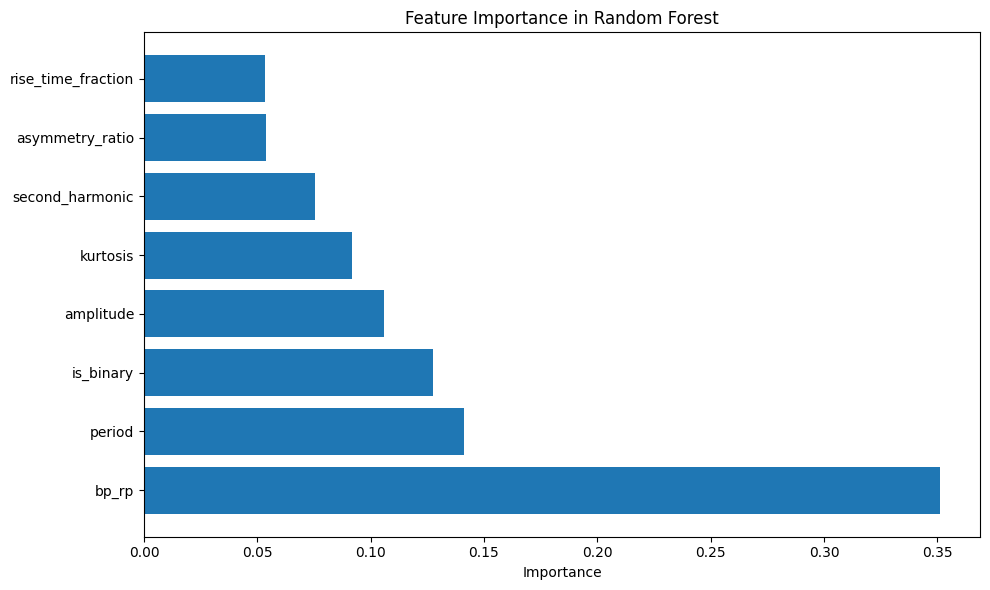

In [24]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance_df.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.tight_layout()
plt.show()

In [35]:
new_observation = pd.DataFrame([{
    'period': 2.0,
    'amplitude': 0.02,
    'asymmetry_ratio': 0.95,
    'rise_time_fraction': 0.5,
    'bp_rp': 0.65,
    'kurtosis': 7.0,
    'second_harmonic': 0.06,
    'is_binary': True
}])

prediction = rf_model.predict(new_observation)
probabilities = rf_model.predict_proba(new_observation)

print(f"\nPredicted class: {prediction[0]}")
print(f"Class probabilities:")
for class_name, prob in zip(rf_model.classes_, probabilities[0]):
    print(f"  {class_name}: {prob:.4f} ({prob*100:.1f}%)")

print("\n" + "="*70)
print("COMPLETE! Your Random Forest model is trained and ready to use.")
print("="*70)


Predicted class: EB
Class probabilities:
  BY: 0.0000 (0.0%)
  CC1: 0.0000 (0.0%)
  DSCT: 0.0000 (0.0%)
  DSS: 0.0000 (0.0%)
  EB: 0.9550 (95.5%)
  GDOR: 0.0100 (1.0%)
  LPV: 0.0033 (0.3%)
  MV: 0.0000 (0.0%)
  NOID: 0.0000 (0.0%)
  OSARG: 0.0067 (0.7%)
  RGV: 0.0000 (0.0%)
  ROT: 0.0250 (2.5%)

COMPLETE! Your Random Forest model is trained and ready to use.
